## CONSTRAINED

In [17]:
import sys
import os

sys.path.append(os.path.abspath(".."))
#IMPORTS
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
from src.visualizacion import *
from src.evaluacion import *
from src.metricas import *
from src.preprocesamiento import *
from src.io_utils import *
from src.sobi import *
from scipy import signal
from src.constrained_ica import *
#VARIABLES
fs=1000
window_size=200
salto=50

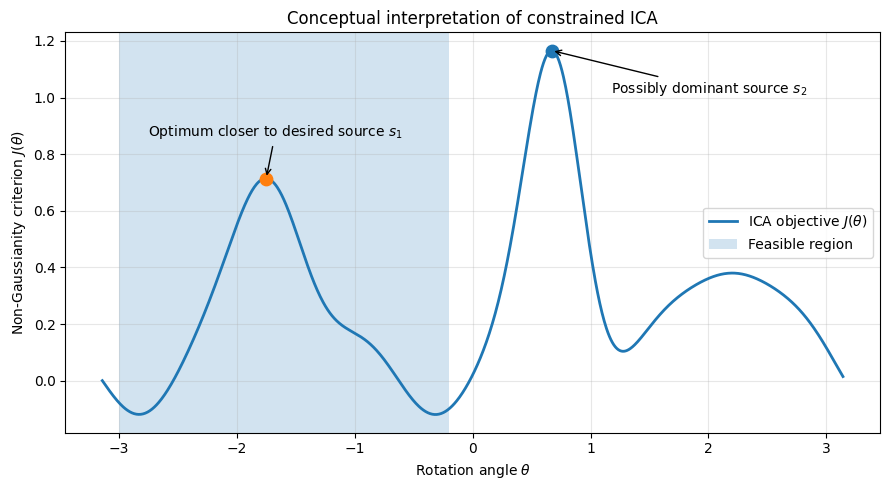

In [18]:
#Rotation angle
theta = np.linspace(-np.pi, np.pi, 1000)

#Conceptual non-convex ICA objective
#This is NOT real negentropy, just an illustrative objective landscape
J = (
    0.8 * np.exp(-((theta + 1.7) ** 2) / 0.18)
    + 1.2 * np.exp(-((theta - 0.7) ** 2) / 0.12)
    + 0.5 * np.exp(-((theta - 2.2) ** 2) / 0.25)
    + 0.12 * np.sin(5 * theta)
)

#Constraint region
theta_min = -3
theta_max = -0.2

#Find unconstrained maximum
idx_unconstrained = np.argmax(J)
theta_unconstrained = theta[idx_unconstrained]
J_unconstrained = J[idx_unconstrained]

# Find constrained maximum
mask = (theta >= theta_min) & (theta <= theta_max)
idx_constrained_local = np.argmax(J[mask])
theta_constrained = theta[mask][idx_constrained_local]
J_constrained = J[mask][idx_constrained_local]

plt.figure(figsize=(9, 5))
#objective
plt.plot(theta, J, linewidth=2, label=r"ICA objective $J(\theta)$")

#feasible region
plt.axvspan(theta_min, theta_max, alpha=0.2, label="Feasible region")

#Unconstrained optimum
plt.scatter(theta_unconstrained, J_unconstrained, s=80, zorder=3)
plt.annotate(
    "Possibly dominant source $s_2$",
    xy=(theta_unconstrained, J_unconstrained),
    xytext=(theta_unconstrained + 0.5, J_unconstrained - 0.15),
    arrowprops=dict(arrowstyle="->"),
)

#Constrained optimum
plt.scatter(theta_constrained, J_constrained, s=80, zorder=3)
plt.annotate(
    "Optimum closer to desired source $s_1$",
    xy=(theta_constrained, J_constrained),
    xytext=(theta_constrained - 1.0, J_constrained + 0.15),
    arrowprops=dict(arrowstyle="->"),
)

plt.xlabel(r"Rotation angle $\theta$")
plt.ylabel(r"Non-Gaussianity criterion $J(\theta)$")
plt.title("Conceptual interpretation of constrained ICA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
mat=load_mat("C:/Users/34648/Desktop/Clases/4_GITT/TFG/OPENICPSR/TR2_postTMR_32chanEMG.mat")

In [3]:
X1, key1 = find_movement_rep(mat, movement="HandOpen", rep=1)
X2, key2 = find_movement_rep(mat, movement="noMotion", rep=1)  

print("Señal 1 extraída de:", key1)
print("Señal 2 extraída de:", key2)


ch_s1 = 3
ch_s2 = 20

u1 = eliminar_continua(X1[:, ch_s1].astype(float))
u2_raw = eliminar_continua(X1[:, ch_s2].astype(float))  


#Longitudes
N = min(len(u1), len(u2_raw))
u1 = u1[:N]

u2_raw = u2_raw[:N]
N = len(u1)
t = np.arange(N) / fs

m1 = np.zeros(N)
m2 = np.zeros(N)
m3 = np.zeros(N)
#bloques 5 segundos
bloque = int(0.2 * fs)
bloque2 = int(0.2 * fs)


patron = [0, 3, 2,1, 3, 3, 1, 2, 3, 0,2, 3,1]

for i, estado in enumerate(patron):
    a = i * bloque
    a2= i * bloque2
    b = min((i + 1) * bloque, N)
    b2= min((i + 1) * bloque2, N)
    if estado == 1:
        m1[a:b] = 1.0
        m3[a:b] = 1.0
    elif estado == 2:
        m2[a2:b2] = 1.0
    elif estado == 3:
        m1[a:b] = 1.0
        m3[a:b] = 1.0
        m2[a2:b2] = 1.0


#CONSTRUCCION DE SEÑALES

s1 = m1 * u1
s2 = m2 * u2_raw


#RETARDOS DE S2
tau_ms = 10
tau = int(fs * tau_ms / 1000)

s2_delayed = np.zeros_like(s2)

if tau < len(s2):
    s2_delayed[tau:] = s2[:-tau]

#MEZCLAS
beta = 1
noise_std = 0.0

rng = np.random.default_rng(0)
n1 = noise_std * rng.standard_normal(len(s1))
n2 = noise_std * rng.standard_normal(len(s1))

c1 = 1.0 * s1 + beta * s2_delayed + n1
c2 = 0.01 * s1 + 1.0 * s2 + n2

X_mix = np.column_stack([c1, c2])
S_true = np.column_stack([s1, s2_delayed])

Señal 1 extraída de: HandOpen_1.DAQ_DATA
Señal 2 extraída de: NoMotion_1.DAQ_DATA


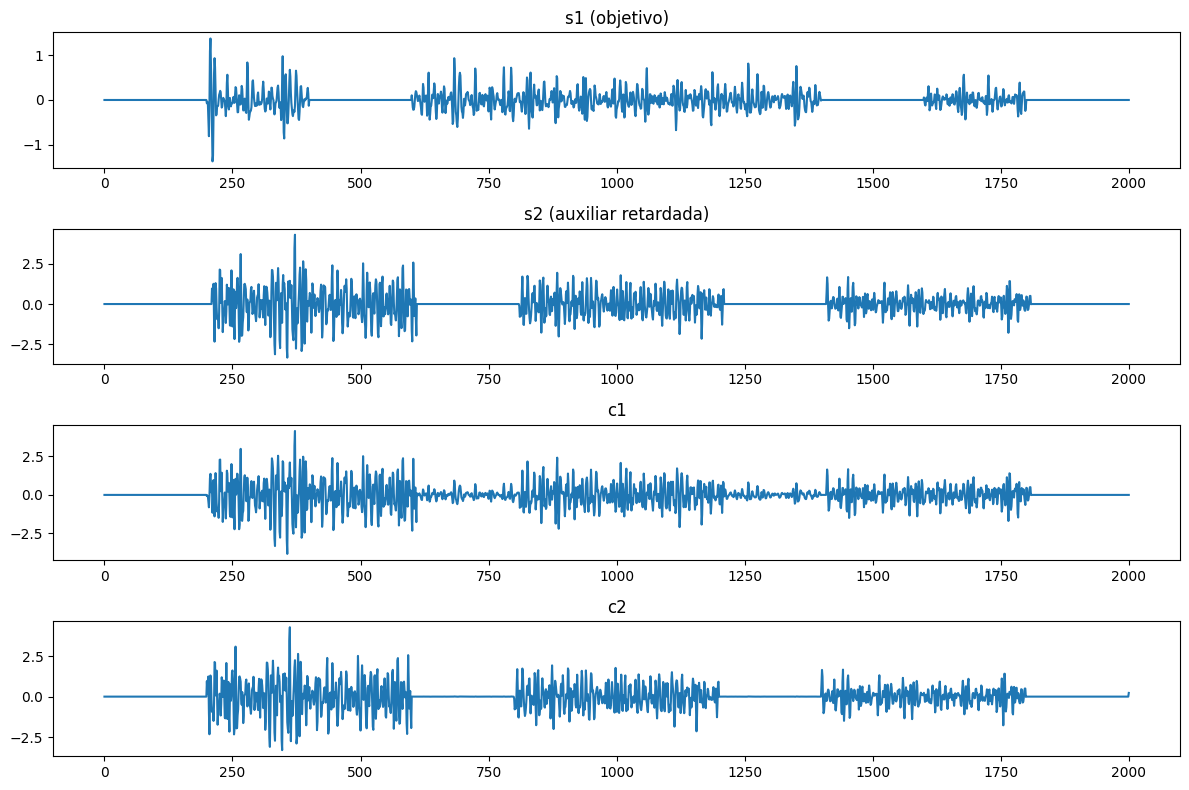

In [4]:
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(s1)
plt.title("s1 (objetivo)")

plt.subplot(4, 1, 2)
plt.plot(s2_delayed)
plt.title("s2 (auxiliar retardada)")

plt.subplot(4, 1, 3)
plt.plot(c1)
plt.title("c1")

plt.subplot(4, 1, 4)
plt.plot(c2)
plt.title("c2")

plt.tight_layout()
plt.show()

# 1unit_constrained

In [5]:
case = build_case(
    u1=u1, u2_raw=u2_raw, fs=fs,
    a11=1.0, a21=0.01, beta=1,
    tau_ms=2.0, noise_std=0.1,
    block_ms=200,
    random_state=0
)

X = case["X"]
S_true = case["S_true"]

In [6]:
ref_s1_binary = m1.astype(float)
ref_env = np.abs(s1)
ref_env = np.convolve(ref_env, np.ones(50)/50, mode="same")
ref_env = ref_env / (np.max(ref_env) + 1e-12)
y_c, w_c, info = constrained_fastica_oneunit(
    X,
    ref=ref_s1_binary,         
    lambda_ref=0.0,
    max_lag=2,
    random_state=0,
    smooth_ref=True,
    smooth_win=75,
    init_mode="ref"
)

In [7]:
from src.metricas import safe_corr, rms_envelope_metrics, snr_db

corr = safe_corr(y_c, s1)
env = rms_envelope_metrics(s1, y_c, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_c)

print("corr =", corr)
print("corr_rms =", env["corr_rms"])
print("snr_db =", snr)
print("best_lag =", info["best_lag"])

corr = 0.041896682497501905
corr_rms = -0.15542403340283076
snr_db = 0.007630006021302403
best_lag = 0


In [8]:
results = []

for lam in [0.0, 0.05, 0.1, 0.2]:
    y_c, w_c, info = constrained_fastica_oneunit(
        X,
        ref=ref_s1_binary,         
        lambda_ref=lam,
        max_lag=5,
        random_state=0,
        smooth_ref=True,
        smooth_win=25,
        init_mode="ref"
    )

    corr = safe_corr(y_c, s1)
    env = rms_envelope_metrics(s1, y_c, fs=1000, window_ms=150, step_ms=50)
    snr = snr_db(s1, y_c)

    results.append({
        "lambda_ref": lam,
        "corr": corr,
        "abs_corr": abs(corr),
        "corr_rms": env["corr_rms"],
        "snr_db": snr,
        "best_lag": info["best_lag"],
        "q_score": info["q_score"],
        "n_iter": info["n_iter"],
        "converged": info["converged"],
    })

df_results = pd.DataFrame(results)
display(df_results.sort_values("lambda_ref").reset_index(drop=True))

,lambda_ref,corr,abs_corr,corr_rms,snr_db,best_lag,q_score,n_iter,converged
0,0.00,0.041882,0.041882,-0.155423,0.007624,0,0.008463,71,True
1,0.05,-0.047579,0.047579,-0.155640,0.009842,0,0.008463,1000,False
2,0.10,-0.314129,0.314129,0.037928,0.451195,0,0.008463,16,True
3,0.20,-0.071070,0.071070,-0.154338,0.021992,0,0.008463,1000,False


In [9]:
import pandas as pd
from sklearn.decomposition import FastICA
from src.metricas import safe_corr, rms_envelope_metrics, snr_db

results = []


ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)
S_hat = ica.fit_transform(X)

#escoger la componente que mejor correlacione con s1
corrs = [safe_corr(S_hat[:, i], s1) for i in range(S_hat.shape[1])]
best_idx = int(abs(corrs[1]) > abs(corrs[0]))
y_ica = S_hat[:, best_idx]

corr = safe_corr(y_ica, s1)
env = rms_envelope_metrics(s1, y_ica, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_ica)

results.append({
    "method": "FastICA",
    "lambda_ref": None,
    "corr": corr,
    "abs_corr": abs(corr),
    "corr_rms": env["corr_rms"],
    "snr_db": snr,
    "best_lag": None,
    "q_score": None,
})


for lam in [0.0, 0.05, 0.1, 0.2,0.5,1,10,50,100]:
    y_c, w_c, info = constrained_fastica_oneunit(
        X,
        ref=ref_s1_binary,
        lambda_ref=lam,
        max_lag=5,
        random_state=72,
        smooth_ref=True,
        smooth_win=50,
        init_mode="ref"
    )

    corr = safe_corr(y_c, s1)
    env = rms_envelope_metrics(s1, y_c, fs=1000, window_ms=150, step_ms=50)
    snr = snr_db(s1, y_c)

    results.append({
        "method": "Constrained one-unit",
        "lambda_ref": lam,
        "corr": corr,
        "abs_corr": abs(corr),
        "corr_rms": env["corr_rms"],
        "snr_db": snr,
        "best_lag": info["best_lag"],
        "q_score": info["q_score"],
    })

df_results = pd.DataFrame(results)
display(df_results.reset_index(drop=True))

,method,lambda_ref,corr,abs_corr,corr_rms,snr_db,best_lag,q_score
0,FastICA,NaN,-0.234846,0.234846,0.000706,0.246384,NaN,NaN
1,Constrained one-unit,0.00,0.041845,0.041845,-0.155421,0.007611,0.0,0.008356
2,Constrained one-unit,0.05,-0.047606,0.047606,-0.155641,0.009854,0.0,0.008356
3,Constrained one-unit,0.10,-0.317580,0.317580,0.053278,0.461714,0.0,0.008356
4,Constrained one-unit,0.20,-0.072870,0.072870,-0.154092,0.023123,0.0,0.008356
5,Constrained one-unit,0.50,-0.130980,0.130980,-0.135936,0.075153,0.0,0.008356
6,Constrained one-unit,1.00,-0.212069,0.212069,-0.083101,0.199845,0.0,0.008356
7,Constrained one-unit,10.00,-0.294008,0.294008,0.046951,0.392633,0.0,0.008356
8,Constrained one-unit,50.00,-0.294089,0.294089,0.047005,0.392859,0.0,0.008356
9,Constrained one-unit,100.00,-0.294098,0.294098,0.047011,0.392883,0.0,0.008356


# DUAL REF

In [10]:
ref_s1_binary = m1.astype(float)
ref_s2_binary = m2.astype(float)

In [11]:
case = build_case(
    u1=u1, u2_raw=u2_raw, fs=fs,
    a11=1, a21=0.01, beta=0.3,
    tau_ms=5.0, noise_std=0.1,
    block_ms=200,
    random_state=0
)

X = case["X"]
S_true = case["S_true"]
m1=case["m1"]
m2=case["m2"]
ref_s1_binary = m1.astype(float)
ref_s2_binary = m2.astype(float)
s1=case["s1"]
s2_delayed=case["s2"]

Best lambda_pos: 0.1
Best lambda_neg: 0.1
Best corr_rms: 0.6846329617475995
Best abs_corr: 0.6725770548869954
Best snr_db: 2.615044784472056


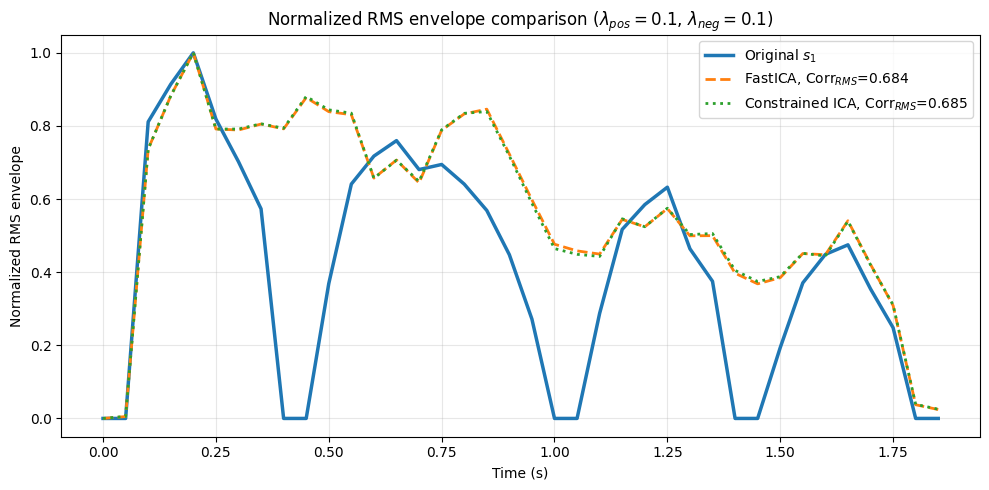

,method,lambda_pos,lambda_neg,corr,abs_corr,corr_rms,snr_db,lag_target,lag_bad,score_target,score_bad,converged,lag_s1,lag_s2,score_s1,score_s2
0,FastICA,NaN,NaN,0.674085,0.674085,0.683706,2.631176,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
1,Dual-ref constrained,0.0,0.00,-0.674049,0.674049,0.683801,2.630797,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
2,Dual-ref constrained,0.0,0.05,0.670859,0.670859,0.683267,2.596774,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
3,Dual-ref constrained,0.0,0.10,-0.668661,0.668661,0.680367,2.573595,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
4,Dual-ref constrained,0.0,0.20,0.666371,0.666371,0.676658,2.549642,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,Dual-ref constrained,10.0,0.50,-0.661977,0.661977,0.668477,2.504280,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
78,Dual-ref constrained,10.0,1.00,-0.661983,0.661983,0.668490,2.504351,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
79,Dual-ref constrained,10.0,2.00,-0.661989,0.661989,0.668502,2.504412,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
80,Dual-ref constrained,10.0,5.00,-0.661997,0.661997,0.668518,2.504492,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962


,method,lambda_pos,lambda_neg,corr,abs_corr,corr_rms,snr_db,lag_target,lag_bad,score_target,score_bad,converged,lag_s1,lag_s2,score_s1,score_s2
0,Dual-ref constrained,0.00,0.00,-0.674049,0.674049,0.683801,2.630797,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
1,Dual-ref constrained,0.10,0.10,-0.672577,0.672577,0.684633,2.615045,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
2,Dual-ref constrained,0.05,0.00,0.670861,0.670861,0.683269,2.596799,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
3,Dual-ref constrained,0.00,0.05,0.670859,0.670859,0.683267,2.596774,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
4,Dual-ref constrained,0.10,0.05,-0.670193,0.670193,0.682484,2.589730,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,Dual-ref constrained,0.50,0.20,-0.660217,0.660217,0.664946,2.486337,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
77,Dual-ref constrained,0.50,0.10,-0.659880,0.659880,0.664255,2.482904,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
78,Dual-ref constrained,0.50,0.05,-0.659654,0.659654,0.663791,2.480611,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962
79,Dual-ref constrained,0.50,0.00,-0.659388,0.659388,0.663244,2.477918,NaN,NaN,NaN,NaN,True,0.0,0.0,0.018366,0.200962


In [ ]:
import pandas as pd
from sklearn.decomposition import FastICA
from src.metricas import safe_corr, rms_envelope_metrics, snr_db


results = []


ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)
S_hat = ica.fit_transform(X)

corrs = [safe_corr(S_hat[:, i], s1) for i in range(S_hat.shape[1])]
best_idx = int(abs(corrs[1]) > abs(corrs[0]))
y_ica = S_hat[:, best_idx]

corr = safe_corr(y_ica, s1)
env = rms_envelope_metrics(s1, y_ica, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_ica)

results.append({
    "method": "FastICA",
    "lambda_pos": None,
    "lambda_neg": None,
    "corr": corr,
    "abs_corr": abs(corr),
    "corr_rms": env["corr_rms"],
    "snr_db": snr,
    "lag_target": None,
    "lag_bad": None,
    "score_target": None,
    "score_bad": None,
    "converged": None,
})


#lambda_pos_values = [0.0, 0.2,0.5,0.75,1,5,10]
#lambda_neg_values = [0.0, 0.05, 0.1, 0.2, 0.5,1,5]

lambda_pos_values = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
lambda_neg_values = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

for lam_pos in lambda_pos_values:
    for lam_neg in lambda_neg_values:

        init_mode = "random" if (lam_pos == 0 and lam_neg == 0) else "target"

        y_dual, w_dual, info_dual = constrained_fastica_dualref_twounits(
            X,
            ref_s1=ref_s1_binary,
            ref_s2=s2_delayed,
            lambda_pos=lam_pos,
            lambda_neg=lam_neg,
            max_lag=0,
            random_state=54,
            smooth_ref=True,
            smooth_win=20
        )

        S_dual = y_dual

        corrs = [safe_corr(S_dual[:, i], s1) for i in range(S_dual.shape[1])]
        best_idx = int(abs(corrs[1]) > abs(corrs[0]))

        y_s1_dual = S_dual[:, best_idx]

        corr = safe_corr(y_s1_dual, s1)
        env = rms_envelope_metrics(s1, y_s1_dual, fs=1000, window_ms=150, step_ms=50)
        snr = snr_db(s1, y_s1_dual)

        results.append({
            "method": "Dual-ref constrained",
            "lambda_pos": lam_pos,
            "lambda_neg": lam_neg,
            "corr": corr,
            "abs_corr": abs(corr),
            "corr_rms": env["corr_rms"],
            "snr_db": snr,
            "lag_s1": info_dual["lag_s1"],
            "lag_s2": info_dual["lag_s2"],
            "score_s1": info_dual["score_s1"],
            "score_s2": info_dual["score_s2"],
            "converged": info_dual["converged"],
        })

df_dual = pd.DataFrame(results)
import numpy as np
import matplotlib.pyplot as plt
from src.metricas import moving_rms

#selecte best
df_constrained = df_dual[df_dual["method"] == "Dual-ref constrained"].copy()

best_row = (
    df_constrained
    .sort_values(["corr_rms", "abs_corr", "snr_db"], ascending=False)
    .iloc[0]
)

best_lambda_pos = float(best_row["lambda_pos"])
best_lambda_neg = float(best_row["lambda_neg"])

print("Best lambda_pos:", best_lambda_pos)
print("Best lambda_neg:", best_lambda_neg)
print("Best corr_rms:", best_row["corr_rms"])
print("Best abs_corr:", best_row["abs_corr"])
print("Best snr_db:", best_row["snr_db"])



ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)

S_hat = ica.fit_transform(X)

corrs = [safe_corr(S_hat[:, i], s1) for i in range(S_hat.shape[1])]
best_idx_ica = int(abs(corrs[1]) > abs(corrs[0]))
y_ica = S_hat[:, best_idx_ica]

#align
if safe_corr(y_ica, s1) < 0:
    y_ica = -y_ica

S_dual, W_dual, info_dual = constrained_fastica_dualref_twounits(
    X,
    ref_s1=ref_s1_binary,
    ref_s2=s2_delayed,
    lambda_pos=best_lambda_pos,
    lambda_neg=best_lambda_neg,
    max_lag=0,
    random_state=54,
    smooth_ref=True,
    smooth_win=20
)

corrs = [safe_corr(S_dual[:, i], s1) for i in range(S_dual.shape[1])]
best_idx_dual = int(abs(corrs[1]) > abs(corrs[0]))
y_dual = S_dual[:, best_idx_dual]


if safe_corr(y_dual, s1) < 0:
    y_dual = -y_dual



fs = 1000
window_ms = 150
step_ms = 50

win_samples = int(fs * window_ms / 1000)
step_samples = int(fs * step_ms / 1000)

rms_s1 = moving_rms(s1, win_samples, step_samples)
rms_ica = moving_rms(y_ica, win_samples, step_samples)
rms_dual = moving_rms(y_dual, win_samples, step_samples)

#match lengths
min_len = min(len(rms_s1), len(rms_ica), len(rms_dual))
rms_s1 = rms_s1[:min_len]
rms_ica = rms_ica[:min_len]
rms_dual = rms_dual[:min_len]

#normalize for fair comparison
eps = 1e-12
def minmax_norm(x, eps=1e-12):
    return (x - np.min(x)) / (np.max(x) - np.min(x) + eps)

rms_s1_norm = minmax_norm(rms_s1)
rms_ica_norm = minmax_norm(rms_ica)
rms_dual_norm = minmax_norm(rms_dual)

t_rms = np.arange(min_len) * (step_ms / 1000)


#metrics
env_ica = rms_envelope_metrics(
    s1, y_ica,
    fs=fs,
    window_ms=window_ms,
    step_ms=step_ms
)

env_dual = rms_envelope_metrics(
    s1, y_dual,
    fs=fs,
    window_ms=window_ms,
    step_ms=step_ms
)

corr_rms_ica = env_ica["corr_rms"]
corr_rms_dual = env_dual["corr_rms"]


#plot RMS
plt.figure(figsize=(10, 5))

plt.plot(
    t_rms,
    rms_s1_norm,
    linewidth=2.5,
    label=r"Original $s_1$"
)

plt.plot(
    t_rms,
    rms_ica_norm,
    linewidth=2,
    linestyle="--",
    label=fr"FastICA, Corr$_{{RMS}}$={corr_rms_ica:.3f}"
)

plt.plot(
    t_rms,
    rms_dual_norm,
    linewidth=2,
    linestyle=":",
    label=fr"Constrained ICA, Corr$_{{RMS}}$={corr_rms_dual:.3f}"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized RMS envelope")
plt.title(
    fr"Normalized RMS envelope comparison "
    fr"($\lambda_{{pos}}={best_lambda_pos}$, "
    fr"$\lambda_{{neg}}={best_lambda_neg}$)"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(df_dual)

display(
    df_dual[df_dual["method"] == "Dual-ref constrained"]
    .sort_values(["abs_corr", "corr_rms", "snr_db"], ascending=False)
    .reset_index(drop=True)
)

In [13]:
dual_only = df_dual[df_dual["method"] == "Dual-ref constrained"].copy()

pivot_abs_corr = dual_only.pivot(index="lambda_pos", columns="lambda_neg", values="abs_corr")
pivot_corr_rms = dual_only.pivot(index="lambda_pos", columns="lambda_neg", values="corr_rms")
pivot_snr = dual_only.pivot(index="lambda_pos", columns="lambda_neg", values="snr_db")

print("Mapa abs_corr")
display(pivot_abs_corr)

print("Mapa corr_rms")
display(pivot_corr_rms)

print("Mapa snr_db")
display(pivot_snr)

Mapa abs_corr


lambda_neg,0.00,0.05,0.10,0.20,0.50,1.00,2.00,5.00,10.00
lambda_pos,,,,,,,,,
0.00,0.674049,0.670859,0.668661,0.666371,0.664146,0.663188,0.662659,0.662322,0.662207
0.05,0.670861,0.668665,0.667288,0.665725,0.663985,0.663141,0.662645,0.662320,0.662207
0.10,0.666780,0.670193,0.672577,0.665243,0.663843,0.663096,0.662633,0.662318,0.662206
0.20,0.653714,0.667874,0.665265,0.664594,0.663622,0.663018,0.662612,0.662312,0.662205
0.50,0.659388,0.659654,0.659880,0.660217,0.663209,0.662833,0.662539,0.662301,0.662202
1.00,0.660828,0.660895,0.660957,0.661040,0.661287,0.662633,0.662489,0.662281,0.662195
2.00,0.661481,0.661496,0.661508,0.661541,0.661610,0.661706,0.662354,0.662266,0.662183
5.00,0.661852,0.661854,0.661856,0.661860,0.661875,0.661889,0.661907,0.662235,0.662182
10.00,0.661972,0.661973,0.661973,0.661974,0.661977,0.661983,0.661989,0.661997,0.662177


Mapa corr_rms


lambda_neg,0.00,0.05,0.10,0.20,0.50,1.00,2.00,5.00,10.00
lambda_pos,,,,,,,,,
0.00,0.683801,0.683267,0.680367,0.676658,0.672649,0.670834,0.669813,0.669156,0.668931
0.05,0.683269,0.680372,0.678204,0.675527,0.672348,0.670744,0.669787,0.669152,0.668929
0.10,0.677356,0.682484,0.684633,0.674666,0.672081,0.670657,0.669763,0.669148,0.668928
0.20,0.651087,0.679151,0.674705,0.673482,0.671663,0.670508,0.669721,0.669137,0.668926
0.50,0.663244,0.663791,0.664255,0.664946,0.670876,0.670150,0.669581,0.669114,0.668920
1.00,0.666186,0.666319,0.666445,0.666612,0.667107,0.669762,0.669482,0.669075,0.668907
2.00,0.667495,0.667524,0.667549,0.667613,0.667752,0.667941,0.669217,0.669046,0.668883
5.00,0.668231,0.668235,0.668239,0.668247,0.668276,0.668304,0.668339,0.668986,0.668881
10.00,0.668468,0.668470,0.668470,0.668472,0.668477,0.668490,0.668502,0.668518,0.668872


Mapa snr_db


lambda_neg,0.00,0.05,0.10,0.20,0.50,1.00,2.00,5.00,10.00
lambda_pos,,,,,,,,,
0.00,2.630797,2.596774,2.573595,2.549642,2.526573,2.516707,2.511272,2.507821,2.506641
0.05,2.596799,2.573631,2.559207,2.542922,2.524914,2.516224,2.511135,2.507799,2.506635
0.10,2.553904,2.589730,2.615045,2.537922,2.523455,2.515758,2.511010,2.507775,2.506629
0.20,2.421046,2.565332,2.538150,2.531205,2.521173,2.514962,2.510788,2.507720,2.506618
0.50,2.477918,2.480611,2.482904,2.486337,2.516928,2.513058,2.510048,2.507599,2.506589
1.00,2.492555,2.493231,2.493867,2.494713,2.497234,2.511006,2.509531,2.507397,2.506517
2.00,2.499217,2.499366,2.499492,2.499821,2.500535,2.501512,2.508141,2.507242,2.506396
5.00,2.503008,2.503027,2.503050,2.503091,2.503238,2.503386,2.503566,2.506929,2.506385
10.00,2.504233,2.504243,2.504244,2.504255,2.504280,2.504351,2.504412,2.504492,2.506337


Best lambda_pos: 0.1
Best lambda_neg: 0.1
Best corr_rms: 0.6846329617475995
Best abs_corr: 0.6725770548869954
Best snr_db: 2.615044784472056


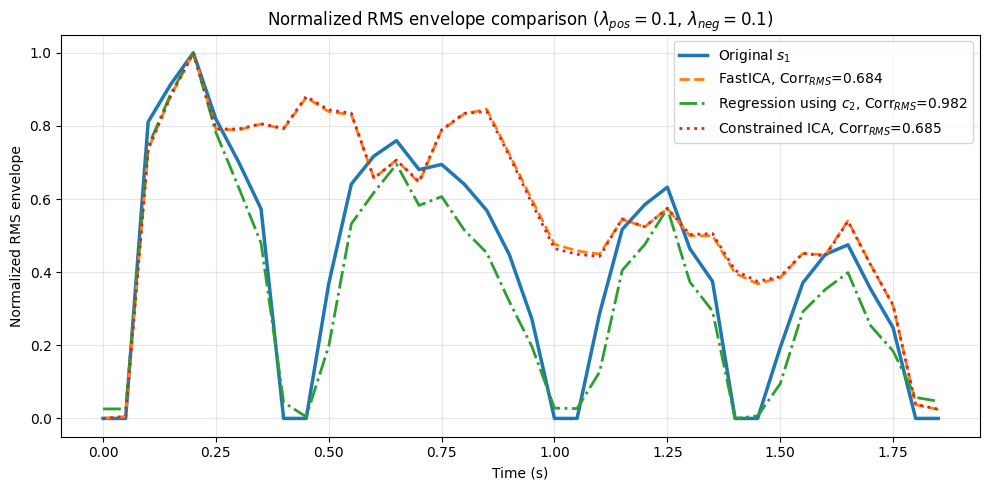

,method,lambda_pos,lambda_neg,corr,abs_corr,corr_rms,snr_db,lag_s1,lag_s2,score_s1,score_s2,converged,beta_hat
0,FastICA,NaN,NaN,0.674085,0.674085,0.683706,2.631176,NaN,NaN,NaN,NaN,None,NaN
1,Regression using c2,NaN,NaN,0.673908,0.673908,0.684404,2.628853,NaN,NaN,NaN,NaN,None,-0.04134
2,Dual-ref constrained,0.0,0.00,0.674049,0.674049,0.683801,2.630797,0.0,0.0,0.018366,0.200962,True,NaN
3,Dual-ref constrained,0.0,0.05,0.670859,0.670859,0.683267,2.596774,0.0,0.0,0.018366,0.200962,True,NaN
4,Dual-ref constrained,0.0,0.10,0.668661,0.668661,0.680367,2.573595,0.0,0.0,0.018366,0.200962,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,Dual-ref constrained,10.0,0.50,0.661977,0.661977,0.668477,2.504280,0.0,0.0,0.018366,0.200962,True,NaN
79,Dual-ref constrained,10.0,1.00,0.661983,0.661983,0.668490,2.504351,0.0,0.0,0.018366,0.200962,True,NaN
80,Dual-ref constrained,10.0,2.00,0.661989,0.661989,0.668502,2.504412,0.0,0.0,0.018366,0.200962,True,NaN
81,Dual-ref constrained,10.0,5.00,0.661997,0.661997,0.668518,2.504492,0.0,0.0,0.018366,0.200962,True,NaN


,method,lambda_pos,lambda_neg,corr,abs_corr,corr_rms,snr_db,lag_s1,lag_s2,score_s1,score_s2,converged,beta_hat
0,FastICA,NaN,NaN,0.674085,0.674085,0.683706,2.631176,NaN,NaN,NaN,NaN,None,NaN
1,Dual-ref constrained,0.00,0.00,0.674049,0.674049,0.683801,2.630797,0.0,0.0,0.018366,0.200962,True,NaN
2,Regression using c2,NaN,NaN,0.673908,0.673908,0.684404,2.628853,NaN,NaN,NaN,NaN,None,-0.04134
3,Dual-ref constrained,0.10,0.10,0.672577,0.672577,0.684633,2.615045,0.0,0.0,0.018366,0.200962,True,NaN
4,Dual-ref constrained,0.05,0.00,0.670861,0.670861,0.683269,2.596799,0.0,0.0,0.018366,0.200962,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,Dual-ref constrained,0.50,0.20,0.660217,0.660217,0.664946,2.486337,0.0,0.0,0.018366,0.200962,True,NaN
79,Dual-ref constrained,0.50,0.10,0.659880,0.659880,0.664255,2.482904,0.0,0.0,0.018366,0.200962,True,NaN
80,Dual-ref constrained,0.50,0.05,0.659654,0.659654,0.663791,2.480611,0.0,0.0,0.018366,0.200962,True,NaN
81,Dual-ref constrained,0.50,0.00,0.659388,0.659388,0.663244,2.477918,0.0,0.0,0.018366,0.200962,True,NaN


,method,lambda_pos,lambda_neg,corr,abs_corr,corr_rms,snr_db,lag_s1,lag_s2,score_s1,score_s2,converged,beta_hat
0,Dual-ref constrained,0.00,0.00,0.674049,0.674049,0.683801,2.630797,0.0,0.0,0.018366,0.200962,True,NaN
1,Dual-ref constrained,0.10,0.10,0.672577,0.672577,0.684633,2.615045,0.0,0.0,0.018366,0.200962,True,NaN
2,Dual-ref constrained,0.05,0.00,0.670861,0.670861,0.683269,2.596799,0.0,0.0,0.018366,0.200962,True,NaN
3,Dual-ref constrained,0.00,0.05,0.670859,0.670859,0.683267,2.596774,0.0,0.0,0.018366,0.200962,True,NaN
4,Dual-ref constrained,0.10,0.05,0.670193,0.670193,0.682484,2.589730,0.0,0.0,0.018366,0.200962,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,Dual-ref constrained,0.50,0.20,0.660217,0.660217,0.664946,2.486337,0.0,0.0,0.018366,0.200962,True,NaN
77,Dual-ref constrained,0.50,0.10,0.659880,0.659880,0.664255,2.482904,0.0,0.0,0.018366,0.200962,True,NaN
78,Dual-ref constrained,0.50,0.05,0.659654,0.659654,0.663791,2.480611,0.0,0.0,0.018366,0.200962,True,NaN
79,Dual-ref constrained,0.50,0.00,0.659388,0.659388,0.663244,2.477918,0.0,0.0,0.018366,0.200962,True,NaN


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import FastICA

from src.metricas import (
    safe_corr,
    rms_envelope_metrics,
    snr_db,
    moving_rms
)


results = []


#ICA baseline

ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)

S_hat = ica.fit_transform(X)

corrs = [safe_corr(S_hat[:, i], s1) for i in range(S_hat.shape[1])]
best_idx = int(abs(corrs[1]) > abs(corrs[0]))

y_ica = S_hat[:, best_idx]

# Align sign
if safe_corr(y_ica, s1) < 0:
    y_ica = -y_ica

corr = safe_corr(y_ica, s1)
env = rms_envelope_metrics(s1, y_ica, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_ica)

results.append({
    "method": "FastICA",
    "lambda_pos": None,
    "lambda_neg": None,
    "corr": corr,
    "abs_corr": abs(corr),
    "corr_rms": env["corr_rms"],
    "snr_db": snr,
    "lag_s1": None,
    "lag_s2": None,
    "score_s1": None,
    "score_s2": None,
    "converged": None,
    "beta_hat": None,
})


#Regression using c2

c1 = X[:, 0]
c2 = X[:, 1]

eps = 1e-12

beta_hat = np.dot(c2, c1) / (np.dot(c2, c2) + eps)

y_reg = c1 - beta_hat * c2

#Align sign
if safe_corr(y_reg, s1) < 0:
    y_reg = -y_reg

corr = safe_corr(y_reg, s1)
env = rms_envelope_metrics(s1, y_reg, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_reg)

results.append({
    "method": "Regression using c2",
    "lambda_pos": None,
    "lambda_neg": None,
    "corr": corr,
    "abs_corr": abs(corr),
    "corr_rms": env["corr_rms"],
    "snr_db": snr,
    "lag_s1": None,
    "lag_s2": None,
    "score_s1": None,
    "score_s2": None,
    "converged": None,
    "beta_hat": beta_hat,
})


#Constrained ICA

lambda_pos_values = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
lambda_neg_values = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

for lam_pos in lambda_pos_values:
    for lam_neg in lambda_neg_values:

        y_dual, w_dual, info_dual = constrained_fastica_dualref_twounits(
            X,
            ref_s1=ref_s1_binary,
            ref_s2=s2_delayed,
            lambda_pos=lam_pos,
            lambda_neg=lam_neg,
            max_lag=0,
            random_state=54,
            smooth_ref=True,
            smooth_win=20
        )

        S_dual = y_dual

        corrs = [safe_corr(S_dual[:, i], s1) for i in range(S_dual.shape[1])]
        best_idx = int(abs(corrs[1]) > abs(corrs[0]))

        y_s1_dual = S_dual[:, best_idx]
        if safe_corr(y_s1_dual, s1) < 0:
            y_s1_dual = -y_s1_dual

        corr = safe_corr(y_s1_dual, s1)
        env = rms_envelope_metrics(s1, y_s1_dual, fs=1000, window_ms=150, step_ms=50)
        snr = snr_db(s1, y_s1_dual)

        results.append({
            "method": "Dual-ref constrained",
            "lambda_pos": lam_pos,
            "lambda_neg": lam_neg,
            "corr": corr,
            "abs_corr": abs(corr),
            "corr_rms": env["corr_rms"],
            "snr_db": snr,
            "lag_s1": info_dual["lag_s1"],
            "lag_s2": info_dual["lag_s2"],
            "score_s1": info_dual["score_s1"],
            "score_s2": info_dual["score_s2"],
            "converged": info_dual["converged"],
            "beta_hat": None,
        })


#results

df_dual = pd.DataFrame(results)


#choose best
df_constrained = df_dual[df_dual["method"] == "Dual-ref constrained"].copy()

best_row = (
    df_constrained
    .sort_values(["corr_rms", "abs_corr", "snr_db"], ascending=False)
    .iloc[0]
)

best_lambda_pos = float(best_row["lambda_pos"])
best_lambda_neg = float(best_row["lambda_neg"])

print("Best lambda_pos:", best_lambda_pos)
print("Best lambda_neg:", best_lambda_neg)
print("Best corr_rms:", best_row["corr_rms"])
print("Best abs_corr:", best_row["abs_corr"])
print("Best snr_db:", best_row["snr_db"])


#rerun FastICA for visualization

ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)

S_hat = ica.fit_transform(X)

corrs = [safe_corr(S_hat[:, i], s1) for i in range(S_hat.shape[1])]
best_idx_ica = int(abs(corrs[1]) > abs(corrs[0]))

y_ica = S_hat[:, best_idx_ica]

if safe_corr(y_ica, s1) < 0:
    y_ica = -y_ica




c1 = X[:, 0]
c2 = X[:, 1]

tau = 5 

#c2 delayed 
c2_lag = np.zeros_like(c2)
c2_lag[tau:] = c2[:-tau]


c1_valid = c1[tau:]
c2_valid = c2_lag[tau:]

beta_hat = np.dot(c2_valid, c1_valid) / (np.dot(c2_valid, c2_valid) + 1e-12)

y_reg = c1.copy()
y_reg[tau:] = c1_valid - beta_hat * c2_valid
y_reg[:tau] = 0  #padding!!!!!!!!!!!!

if safe_corr(y_reg[tau:], s1[tau:]) < 0:
    y_reg = -y_reg



S_dual, W_dual, info_dual = constrained_fastica_dualref_twounits(
    X,
    ref_s1=ref_s1_binary,
    ref_s2=s2_delayed,
    lambda_pos=best_lambda_pos,
    lambda_neg=best_lambda_neg,
    max_lag=5,
    random_state=54,
    smooth_ref=True,
    smooth_win=20
)

corrs = [safe_corr(S_dual[:, i], s1) for i in range(S_dual.shape[1])]
best_idx_dual = int(abs(corrs[1]) > abs(corrs[0]))

y_dual = S_dual[:, best_idx_dual]

if safe_corr(y_dual, s1) < 0:
    y_dual = -y_dual


#compute RMS

fs = 1000
window_ms = 150
step_ms = 50

win_samples = int(fs * window_ms / 1000)
step_samples = int(fs * step_ms / 1000)

rms_s1 = moving_rms(s1, win_samples, step_samples)
rms_ica = moving_rms(y_ica, win_samples, step_samples)
rms_reg = moving_rms(y_reg, win_samples, step_samples)
rms_dual = moving_rms(y_dual, win_samples, step_samples)

min_len = min(
    len(rms_s1),
    len(rms_ica),
    len(rms_reg),
    len(rms_dual)
)

rms_s1 = rms_s1[:min_len]
rms_ica = rms_ica[:min_len]
rms_reg = rms_reg[:min_len]
rms_dual = rms_dual[:min_len]


def minmax_norm(x, eps=1e-12):
    return (x - np.min(x)) / (np.max(x) - np.min(x) + eps)


rms_s1_norm = minmax_norm(rms_s1)
rms_ica_norm = minmax_norm(rms_ica)
rms_reg_norm = minmax_norm(rms_reg)
rms_dual_norm = minmax_norm(rms_dual)

t_rms = np.arange(min_len) * (step_ms / 1000)


#metrics

env_ica = rms_envelope_metrics(
    s1,
    y_ica,
    fs=fs,
    window_ms=window_ms,
    step_ms=step_ms
)

env_reg = rms_envelope_metrics(
    s1,
    y_reg,
    fs=fs,
    window_ms=window_ms,
    step_ms=step_ms
)

env_dual = rms_envelope_metrics(
    s1,
    y_dual,
    fs=fs,
    window_ms=window_ms,
    step_ms=step_ms
)

corr_rms_ica = env_ica["corr_rms"]
corr_rms_reg = env_reg["corr_rms"]
corr_rms_dual = env_dual["corr_rms"]



plt.figure(figsize=(10, 5))

plt.plot(
    t_rms,
    rms_s1_norm,
    linewidth=2.5,
    label=r"Original $s_1$"
)

plt.plot(
    t_rms,
    rms_ica_norm,
    linewidth=2,
    linestyle="--",
    label=fr"FastICA, Corr$_{{RMS}}$={corr_rms_ica:.3f}"
)

plt.plot(
    t_rms,
    rms_reg_norm,
    linewidth=2,
    linestyle="-.",
    label=fr"Regression using $c_2$, Corr$_{{RMS}}$={corr_rms_reg:.3f}"
)

plt.plot(
    t_rms,
    rms_dual_norm,
    linewidth=2,
    linestyle=":",
    label=fr"Constrained ICA, Corr$_{{RMS}}$={corr_rms_dual:.3f}"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized RMS envelope")
plt.title(
    fr"Normalized RMS envelope comparison "
    fr"($\lambda_{{pos}}={best_lambda_pos}$, "
    fr"$\lambda_{{neg}}={best_lambda_neg}$)"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#display results

display(df_dual)

display(
    df_dual
    .sort_values(["abs_corr", "corr_rms", "snr_db"], ascending=False)
    .reset_index(drop=True)
)

display(
    df_dual[df_dual["method"] == "Dual-ref constrained"]
    .sort_values(["abs_corr", "corr_rms", "snr_db"], ascending=False)
    .reset_index(drop=True)
)

In [15]:
results = []


ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)
S_hat = ica.fit_transform(X)

corrs = [safe_corr(S_hat[:, i], s1) for i in range(S_hat.shape[1])]
best_idx = int(abs(corrs[1]) > abs(corrs[0]))
y_ica = S_hat[:, best_idx]

corr = safe_corr(y_ica, s1)
env = rms_envelope_metrics(s1, y_ica, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_ica)

results.append({
    "method": "FastICA",
    "lambda_pos": None,
    "lambda_neg": None,
    "corr": corr,
    "abs_corr": abs(corr),
    "corr_rms": env["corr_rms"],
    "snr_db": snr,
    "lag_target": None,
    "lag_bad": None,
    "score_target": None,
    "score_bad": None,
    "converged": None,
})


lambda_pos_values = np.arange(0.0, 10.1, 0.5)
lambda_neg_values = np.arange(0.0, 10.1, 0.5)

for lam_pos in lambda_pos_values:
    for lam_neg in lambda_neg_values:
        y_dual, w_dual, info_dual = constrained_fastica_dualref_oneunit(
            X,
            ref_target=ref_s1_binary,
            ref_bad=ref_s2_binary,
            lambda_pos=lam_pos,
            lambda_neg=lam_neg,
            max_lag=2,
            random_state=52,
            smooth_ref=True,
            smooth_win=25,
            init_mode="target"
        )

        corr = safe_corr(y_dual, s1)
        env = rms_envelope_metrics(s1, y_dual, fs=1000, window_ms=150, step_ms=50)
        snr = snr_db(s1, y_dual)

        results.append({
            "method": "Dual-ref constrained",
            "lambda_pos": lam_pos,
            "lambda_neg": lam_neg,
            "corr": corr,
            "abs_corr": abs(corr),
            "corr_rms": env["corr_rms"],
            "snr_db": snr,
            "lag_target": info_dual["lag_target"],
            "lag_bad": info_dual["lag_bad"],
            "score_target": info_dual["score_target"],
            "score_bad": info_dual["score_bad"],
            "converged": info_dual["converged"],
        })


df_dual = pd.DataFrame(results)


ica_row = df_dual[df_dual["method"] == "FastICA"].iloc[0]


best_corr_rms_row = (
    df_dual[df_dual["method"] == "Dual-ref constrained"]
    .sort_values("corr_rms", ascending=False)
    .iloc[0]
)

print("=== Mejor combinación dual-ref según corr_rms ===")
print(best_corr_rms_row)
print()

print("=== Comparación con FastICA ===")
print(f"FastICA corr_rms       : {ica_row['corr_rms']:.6f}")
print(f"Best dual corr_rms     : {best_corr_rms_row['corr_rms']:.6f}")
print(f"Diferencia corr_rms    : {best_corr_rms_row['corr_rms'] - ica_row['corr_rms']:.6f}")
print()

print(f"FastICA abs_corr       : {ica_row['abs_corr']:.6f}")
print(f"Best dual abs_corr     : {best_corr_rms_row['abs_corr']:.6f}")
print(f"Diferencia abs_corr    : {best_corr_rms_row['abs_corr'] - ica_row['abs_corr']:.6f}")
print()

print(f"FastICA snr_db         : {ica_row['snr_db']:.6f}")
print(f"Best dual snr_db       : {best_corr_rms_row['snr_db']:.6f}")
print(f"Diferencia snr_db      : {best_corr_rms_row['snr_db'] - ica_row['snr_db']:.6f}")
print()

print("=== Parámetros de la mejor combinación dual-ref ===")
print(f"lambda_pos             : {best_corr_rms_row['lambda_pos']}")
print(f"lambda_neg             : {best_corr_rms_row['lambda_neg']}")
print(f"lag_target             : {best_corr_rms_row['lag_target']}")
print(f"lag_bad                : {best_corr_rms_row['lag_bad']}")
print(f"converged              : {best_corr_rms_row['converged']}")

=== Mejor combinación dual-ref según corr_rms ===
method          Dual-ref constrained
lambda_pos                       5.5
lambda_neg                       2.5
corr                        -0.67297
abs_corr                     0.67297
corr_rms                    0.684722
snr_db                      2.619239
lag_target                       0.0
lag_bad                          2.0
score_target                0.019388
score_bad                   0.003496
converged                       True
Name: 237, dtype: object

=== Comparación con FastICA ===
FastICA corr_rms       : 0.683706
Best dual corr_rms     : 0.684722
Diferencia corr_rms    : 0.001016

FastICA abs_corr       : 0.674085
Best dual abs_corr     : 0.672970
Diferencia abs_corr    : -0.001115

FastICA snr_db         : 2.631176
Best dual snr_db       : 2.619239
Diferencia snr_db      : -0.011937

=== Parámetros de la mejor combinación dual-ref ===
lambda_pos             : 5.5
lambda_neg             : 2.5
lag_target             : 0.